In [75]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [98]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"

fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"
czi_name = "CB5-01_S3.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [120]:
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel)

In [121]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

In [ ]:

def select_roi(img):
    roi, _ = get_roi_from_result(
    result,
    result['rotate_fn'](img) ,
    region= "full",
    pad_left_um=-1500.0,   # expand chip box leftward (µm)
    pad_right_um=-3000.0,  # expand chip box rightward (µm)
    pad_top_um=1300.0,    # pad above & below main channel centre (symmetric)
    pad_bottom_um= 1300
)
    return roi

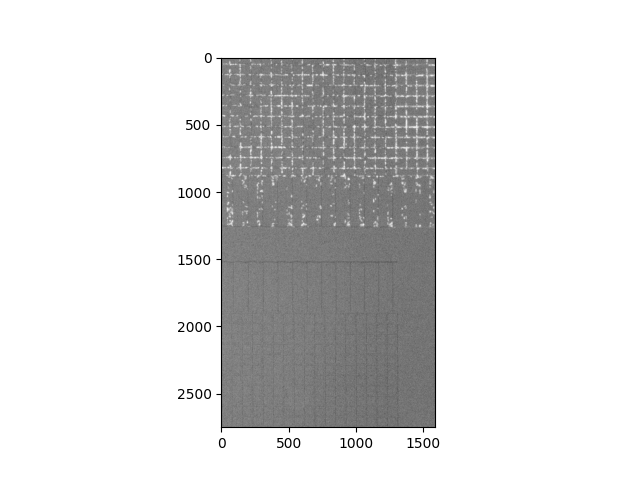

In [123]:

stretch_min = 10
stretch_max = 99.5
channel = 1
time = 0
img, img_disp = get_frame(czi,time,channel,gamma=0.45,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")

Noise gate: 38/81 tiles replaced by global floor (gate=0.4637, global_thresh=0.2282)
Channel 1 — local Triangle threshold (gated)
  Target tile size    : 300.0 µm
  Actual tile grid    : 9×9  (288.9 µm per side)
  Threshold factor    : 0.95
  Threshold range     : 0.2091 – 0.2575
  Total area          : 122,489.6 µm²
  ROI area            : 3,900,068.4 µm²
  Coverage            : 3.14 %


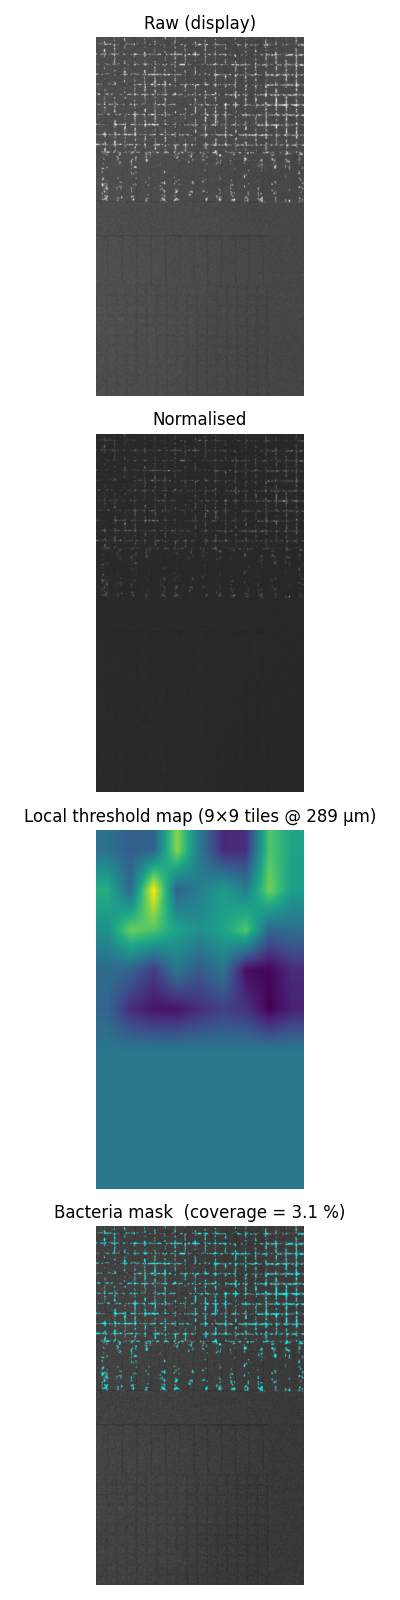

In [103]:

from skimage import exposure, transform
from skimage.filters import threshold_triangle
from skimage.morphology import remove_small_objects, remove_small_holes
import matplotlib.pyplot as plt
import numpy as np

# ── Parameters ───────────────────────────────────────────────────────────────
channel      = 1          # bacteria fluorescence channel
time         = 0

TARGET_TILE_SIZE_UM = 300.0  # target tile size in µm (controls locality)
THRESH_FACTOR       = 0.95   # relaxation factor: 1.0 = strict Triangle, <1 = more permissive

# Noise gate: minimum signal percentile a tile must exceed to use its local threshold.
# If the tile's max intensity is below this global percentile, the tile is considered
# pure background and gets the global floor threshold instead.
# Typical range: 90–99 (percentile of the full image).
SIGNAL_GATE_PERCENTILE = 99.9

# Morphological cleanup
MIN_OBJ_UM2  = 10.0
MAX_HOLE_UM2 = 1

# ── Load & crop ───────────────────────────────────────────────────────────────
px_um = pixel_size["X"]
img_raw, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=1, stretch_max=99.5)
img_raw  = select_roi(img_raw.astype(float))
img_disp = select_roi(img_disp)

img_norm = exposure.rescale_intensity(img_raw, out_range=(0.0, 1.0))
H, W = img_norm.shape

# ── Compute global threshold (used as floor for background tiles) ─────────────
global_thresh = threshold_triangle(img_norm) * THRESH_FACTOR
signal_gate   = np.percentile(img_norm, SIGNAL_GATE_PERCENTILE)

# ── Calculate tile grid ───────────────────────────────────────────────────────
img_height_um = H * px_um
img_width_um  = W * px_um
n_tiles_h = max(1, int(np.ceil(img_height_um / TARGET_TILE_SIZE_UM)))
n_tiles_w = max(1, int(np.ceil(img_width_um  / TARGET_TILE_SIZE_UM)))
TILE_GRID = max(n_tiles_h, n_tiles_w)

actual_tile_size_um = img_height_um / TILE_GRID

# ── Build per-tile threshold map ──────────────────────────────────────────────
thresh_map_coarse = np.zeros((TILE_GRID, TILE_GRID), dtype=float)
n_gated = 0

for row in range(TILE_GRID):
    for col in range(TILE_GRID):
        r0, r1 = int(row * H / TILE_GRID), int((row + 1) * H / TILE_GRID)
        c0, c1 = int(col * W / TILE_GRID), int((col + 1) * W / TILE_GRID)
        tile = img_norm[r0:r1, c0:c1]

        local_thresh = threshold_triangle(tile) * THRESH_FACTOR

        # If the tile's max doesn't reach the signal gate, it's pure background:
        # use the global floor so noise doesn't get segmented.
        if tile.max() < signal_gate:
            thresh_map_coarse[row, col] = global_thresh
            n_gated += 1
        else:
            # Allow the local threshold to go below the global only when there's
            # genuine signal in the tile.
            thresh_map_coarse[row, col] = local_thresh

print(f"Noise gate: {n_gated}/{TILE_GRID**2} tiles replaced by global floor "
      f"(gate={signal_gate:.4f}, global_thresh={global_thresh:.4f})")

# ── Bilinear interpolation back to full image size ────────────────────────────
thresh_map = transform.resize(
    thresh_map_coarse,
    (H, W),
    order=1,
    mode="edge",
    anti_aliasing=False,
)

# ── Apply local threshold ─────────────────────────────────────────────────────
binary = img_norm > thresh_map

# ── Morphological clean-up ────────────────────────────────────────────────────
min_obj_px  = max(1, int(np.round(MIN_OBJ_UM2  / px_um ** 2)))
max_hole_px = max(1, int(np.round(MAX_HOLE_UM2 / px_um ** 2)))
binary = remove_small_objects(binary, max_size=min_obj_px)
binary = remove_small_holes(binary,   max_size=max_hole_px)

# ── Area measurement ──────────────────────────────────────────────────────────
bac_area_um2  = binary.sum() * px_um ** 2
roi_area_um2  = binary.size  * px_um ** 2
bac_fraction  = binary.mean()

print(f"Channel {channel} — local Triangle threshold (gated)")
print(f"  Target tile size    : {TARGET_TILE_SIZE_UM:.1f} µm")
print(f"  Actual tile grid    : {TILE_GRID}×{TILE_GRID}  ({actual_tile_size_um:.1f} µm per side)")
print(f"  Threshold factor    : {THRESH_FACTOR}")
print(f"  Threshold range     : {thresh_map_coarse.min():.4f} – {thresh_map_coarse.max():.4f}")
print(f"  Total area          : {bac_area_um2:,.1f} µm²")
print(f"  ROI area            : {roi_area_um2:,.1f} µm²")
print(f"  Coverage            : {bac_fraction * 100:.2f} %")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(4, 16), sharex=True, sharey=True)

axes[0].imshow(img_disp, cmap="gray")
axes[0].set_title("Raw (display)")

axes[1].imshow(img_norm, cmap="gray")
axes[1].set_title("Normalised")

axes[2].imshow(thresh_map, cmap="viridis")
axes[2].set_title(f"Local threshold map ({TILE_GRID}×{TILE_GRID} tiles @ {actual_tile_size_um:.0f} µm)")

overlay = np.stack([img_disp, img_disp, img_disp], axis=-1).astype(float)
overlay[binary, 0] = 0.0
overlay[binary, 1] = overlay[binary, 1] * 0.3 + 0.7
overlay[binary, 2] = overlay[binary, 2] * 0.3 + 0.7
axes[3].imshow(np.clip(overlay, 0, 1))
axes[3].set_title(f"Bacteria mask  (coverage = {bac_fraction*100:.1f} %)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Create Ground-Truth Training Data

Extracts fixed-size patches from the current ROI + binary mask and saves them as TIFF pairs under  
`TRAINING_DATA_DIR/images/` and `TRAINING_DATA_DIR/masks/`.

Filenames encode the **source file, channel, time and patch position**, so:
- Re-running the same cell is **idempotent** (existing patches are skipped).  
- Changing the CZI file, channel, time-point, or ROI crop **appends** new patches to the same dataset.

In [104]:
import os
import tifffile

# ── Training data parameters ─────────────────────────────────────────────────
TRAINING_DATA_DIR   = "/Users/bisot/Documents/PostDoc2/training_data"
PATCH_SIZE_PX       = 256    # patch side length in pixels (square)
PATCH_STRIDE_PX     = 128    # stride between patch top-left corners (50 % overlap)
MIN_SIGNAL_FRACTION = 0.005  # discard patches with less foreground than this
BALANCE_BACKGROUND  = True   # keep at most as many background as signal patches
SKIP_IF_EXISTS      = True   # idempotent: skip if this patch file already exists

os.makedirs(os.path.join(TRAINING_DATA_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(TRAINING_DATA_DIR, "masks"),  exist_ok=True)

# ── Load ALL channels at the current time point and apply the same ROI crop ───
# Images are saved as (C, H, W) float32 TIFFs so the network sees all channels.
# The binary mask is always derived from the thresholding cell above (channel `channel`).
n_channels = dim_sizes["C"]
channel_imgs = []
for ch in range(n_channels):
    img_ch_raw, _ = get_frame(czi, time, ch, gamma=1, stretch_min=1, stretch_max=99.5)
    img_ch_roi  = select_roi(img_ch_raw.astype(float))
    img_ch_norm = exposure.rescale_intensity(img_ch_roi, out_range=(0.0, 1.0)).astype(np.float32)
    channel_imgs.append(img_ch_norm)

img_multichannel = np.stack(channel_imgs, axis=0)   # (C, H, W)
print(f"Multi-channel image shape : {img_multichannel.shape}  "
      f"(mask derived from channel {channel})")

Multi-channel image shape : (3, 2751, 1587)  (mask derived from channel 1)


In [131]:


# ── Unique source tag (deterministic → re-running won't duplicate) ────────────
source_tag = f"{czi_path.stem}_ch{channel}_t{time}"

# ── Patch extraction ──────────────────────────────────────────────────────────
patches_signal, patches_bg = [], []
H_img, W_img = img_multichannel.shape[1], img_multichannel.shape[2]

for r in range(0, H_img - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
    for c in range(0, W_img - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
        img_patch  = img_multichannel[:, r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX]  # (C, P, P)
        mask_patch = binary[r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX].astype(np.uint8)
        frac       = mask_patch.mean()
        name       = f"{source_tag}_r{r:05d}_c{c:05d}"
        if frac >= MIN_SIGNAL_FRACTION:
            patches_signal.append((img_patch, mask_patch, name))
        else:
            patches_bg.append((img_patch, mask_patch, name))

# Balance: keep at most as many background patches as signal patches ───────────
if BALANCE_BACKGROUND and patches_bg:
    rng  = np.random.default_rng(seed=42)
    n_bg = min(len(patches_bg), max(len(patches_signal), 1))
    idx  = rng.choice(len(patches_bg), size=n_bg, replace=False)
    patches_bg_kept = [patches_bg[i] for i in idx]
else:
    patches_bg_kept = patches_bg

all_patches = patches_signal + patches_bg_kept

# ── Save ──────────────────────────────────────────────────────────────────────
saved, skipped = 0, 0
for img_patch, mask_patch, name in all_patches:
    img_path  = os.path.join(TRAINING_DATA_DIR, "images", f"{name}.tif")
    mask_path = os.path.join(TRAINING_DATA_DIR, "masks",  f"{name}.tif")
    if SKIP_IF_EXISTS and os.path.exists(img_path):
        skipped += 1
        continue
    tifffile.imwrite(img_path,  img_patch)   # (C, H, W)  float32
    tifffile.imwrite(mask_path, mask_patch)  # (H, W)     uint8
    saved += 1

# ── Report ────────────────────────────────────────────────────────────────────
total = len([f for f in os.listdir(os.path.join(TRAINING_DATA_DIR, "images")) if f.endswith(".tif")])
print(f"Source            : {source_tag}")
print(f"Candidate patches : {len(patches_signal)} signal  +  {len(patches_bg_kept)} background"
      f" kept  (from {len(patches_bg)} bg candidates)")
print(f"Saved             : {saved}   Skipped (already exist): {skipped}")
print(f"Dataset total     : {total} patches  →  {TRAINING_DATA_DIR}")

Source            : CB5-01_S3_ch1_t0
Candidate patches : 110 signal  +  110 background kept  (from 110 bg candidates)
Saved             : 220   Skipped (already exist): 0
Dataset total     : 1068 patches  →  /Users/bisot/Documents/PostDoc2/training_data


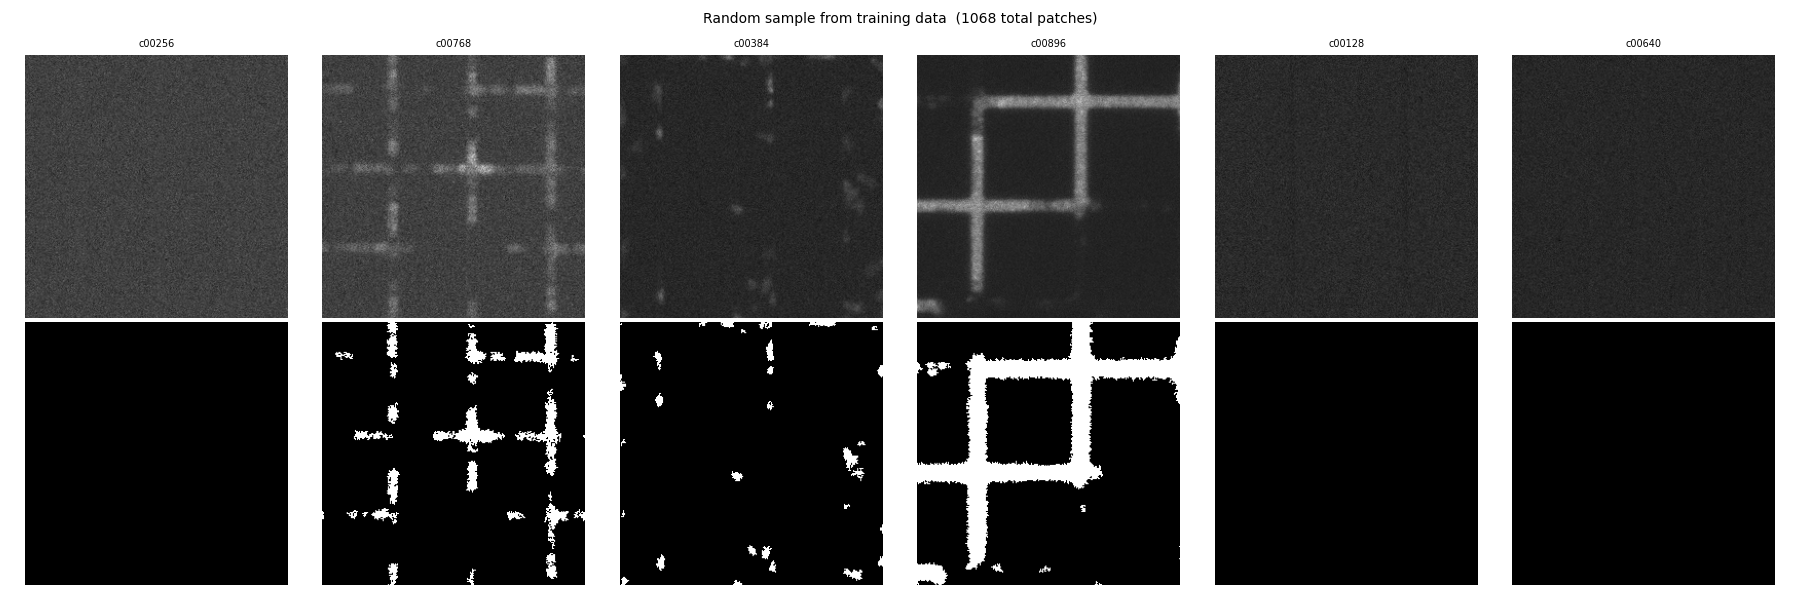

In [132]:
import random
channel = 1
# ── Preview a random sample from the full saved dataset ───────────────────────
img_dir  = os.path.join(TRAINING_DATA_DIR, "images")
mask_dir = os.path.join(TRAINING_DATA_DIR, "masks")

all_names = sorted(f for f in os.listdir(img_dir) if f.endswith(".tif"))
n_show    = min(6, len(all_names))
sample    = random.sample(all_names, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i, fname in enumerate(sample):
    img_p  = tifffile.imread(os.path.join(img_dir,  fname))
    mask_p = tifffile.imread(os.path.join(mask_dir, fname))

    # Multi-channel (C,H,W): show the bacteria channel used for thresholding
    img_disp_p = img_p[channel] if img_p.ndim == 3 else img_p

    axes[0, i].imshow(img_disp_p, cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(fname.replace(".tif", "").rsplit("_", 2)[-1], fontsize=7)
    axes[0, i].axis("off")

    axes[1, i].imshow(mask_p, cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel(f"Ch {channel} (signal)", fontsize=9)
axes[1, 0].set_ylabel("Mask", fontsize=9)
plt.suptitle(f"Random sample from training data  ({len(all_names)} total patches)", fontsize=10)
plt.tight_layout()
plt.show()

## U-Net Training

Classic encoder–decoder U-Net for binary cell segmentation.

- **Input** : `(C, 256, 256)` multi-channel float32 patch — one channel per CZI channel  
- **Output** : `(1, 256, 256)` sigmoid probability map  
- **Loss**  : 0.5 × BCE + 0.5 × Dice  
- **Augmentation** : random flips + 90° rotations (applied on-the-fly)

Run the *model definition* cell once, then the *training* cell as many times as needed (it resumes from the best checkpoint if one exists).

In [133]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ─────────────────────────────────────────────────────────────────────────────
# Building block
# ─────────────────────────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


# ─────────────────────────────────────────────────────────────────────────────
# U-Net
# ─────────────────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    """
    Classic U-Net (Ronneberger et al., 2015) adapted for arbitrary input channels.
    `features` controls the channel progression in the encoder.
    """
    def __init__(self, in_channels: int = 3, out_channels: int = 1,
                 features: list = [32, 64, 128, 256]):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.downs     = nn.ModuleList()
        self.ups_trans = nn.ModuleList()
        self.ups_conv  = nn.ModuleList()

        # Encoder
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for feat in reversed(features):
            self.ups_trans.append(nn.ConvTranspose2d(feat * 2, feat, kernel_size=2, stride=2))
            self.ups_conv.append(DoubleConv(feat * 2, feat))

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i, (up_t, up_c) in enumerate(zip(self.ups_trans, self.ups_conv)):
            x = up_t(x)
            skip = skips[i]
            if x.shape != skip.shape:                         # guard for odd sizes
                x = F.interpolate(x, size=skip.shape[2:])
            x = up_c(torch.cat([skip, x], dim=1))

        return self.final(x)                                  # raw logits


# ─────────────────────────────────────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────────────────────────────────────
class SegmentationDataset(Dataset):
    """
    Loads (C, H, W) image TIFFs + (H, W) binary mask TIFFs.
    Handles both legacy single-channel and new multi-channel images.
    Augmentation: random horizontal/vertical flips + 90° rotations.
    """
    def __init__(self, images_dir: str, masks_dir: str, augment: bool = True):
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.names      = sorted(f for f in os.listdir(images_dir) if f.endswith(".tif"))
        self.augment    = augment

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        fname    = self.names[idx]
        img_arr  = tifffile.imread(os.path.join(self.images_dir, fname)).astype(np.float32)
        mask_arr = tifffile.imread(os.path.join(self.masks_dir,  fname)).astype(np.float32)

        # Ensure (C, H, W)
        if img_arr.ndim == 2:
            img_arr = img_arr[np.newaxis]      # legacy single-channel

        img_t  = torch.from_numpy(img_arr)                     # (C, H, W)
        mask_t = torch.from_numpy(mask_arr).unsqueeze(0)       # (1, H, W)

        if self.augment:
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [2])
                mask_t = torch.flip(mask_t, [2])
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [1])
                mask_t = torch.flip(mask_t, [1])
            k = int(torch.randint(0, 4, (1,)))
            img_t  = torch.rot90(img_t,  k, [1, 2])
            mask_t = torch.rot90(mask_t, k, [1, 2])

        return img_t, mask_t


# ─────────────────────────────────────────────────────────────────────────────
# Quick sanity check
# ─────────────────────────────────────────────────────────────────────────────
_ds_check = SegmentationDataset(
    os.path.join(TRAINING_DATA_DIR, "images"),
    os.path.join(TRAINING_DATA_DIR, "masks"),
    augment=False,
)
_img0, _mask0 = _ds_check[0]
N_CHANNELS = _img0.shape[0]
print(f"Dataset size     : {len(_ds_check)} patches")
print(f"Image shape      : {tuple(_img0.shape)}   (C={N_CHANNELS}, patch={_img0.shape[1]}px)")
print(f"Mask shape       : {tuple(_mask0.shape)}")

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps")  if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Device           : {device}")

model = UNet(in_channels=N_CHANNELS, out_channels=1, features=[32, 64, 128, 256]).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters : {n_params:,}")

Dataset size     : 1068 patches
Image shape      : (3, 256, 256)   (C=3, patch=256px)
Mask shape       : (1, 256, 256)
Device           : mps
U-Net parameters : 7,763,041


In [135]:
import torch.optim as optim

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS    = 150
BATCH_SIZE  = 8
LR          = 1e-4
VAL_SPLIT   = 0.2          # fraction of patches held out for validation
MODEL_SAVE  = os.path.join(TRAINING_DATA_DIR, "unet_best.pth")

# ── Dataset split ─────────────────────────────────────────────────────────────
full_ds  = SegmentationDataset(
    os.path.join(TRAINING_DATA_DIR, "images"),
    os.path.join(TRAINING_DATA_DIR, "masks"),
    augment=True,
)
n_val    = max(1, int(len(full_ds) * VAL_SPLIT))
n_train  = len(full_ds) - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)
val_ds.dataset.augment = False   # no augmentation for validation

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f"Train: {n_train} patches   Val: {n_val} patches")

# ── Model, optimiser, scheduler ───────────────────────────────────────────────
model     = UNet(in_channels=N_CHANNELS, out_channels=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Resume from checkpoint if available
start_epoch = 1
if os.path.exists(MODEL_SAVE):
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))
    print(f"Resumed from checkpoint: {MODEL_SAVE}")

# ── Loss ──────────────────────────────────────────────────────────────────────
def dice_loss(logits, target, eps=1e-6):
    pred  = torch.sigmoid(logits)
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - (2 * inter + eps) / (union + eps)

def criterion(logits, target):
    bce  = F.binary_cross_entropy_with_logits(logits, target)
    dice = dice_loss(logits, target).mean()
    return 0.5 * bce + 0.5 * dice

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val = float("inf")

for epoch in range(start_epoch, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    t_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    # --- Validate ---
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            v_loss += criterion(model(imgs), masks).item()
    v_loss /= len(val_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), MODEL_SAVE)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS}  train={t_loss:.4f}  val={v_loss:.4f}  best={best_val:.4f}")

print(f"\nBest model saved → {MODEL_SAVE}")

# ── Loss curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE + Dice loss")
ax.legend()
ax.set_title("U-Net training")
plt.tight_layout()
plt.show()

Train: 855 patches   Val: 213 patches
Epoch   1/150  train=0.7173  val=0.6487  best=0.6487
Epoch   5/150  train=0.5575  val=0.5341  best=0.5341
Epoch  10/150  train=0.4636  val=0.4605  best=0.4605
Epoch  15/150  train=0.4036  val=0.3983  best=0.3983
Epoch  20/150  train=0.3564  val=0.3625  best=0.3625


KeyboardInterrupt: 

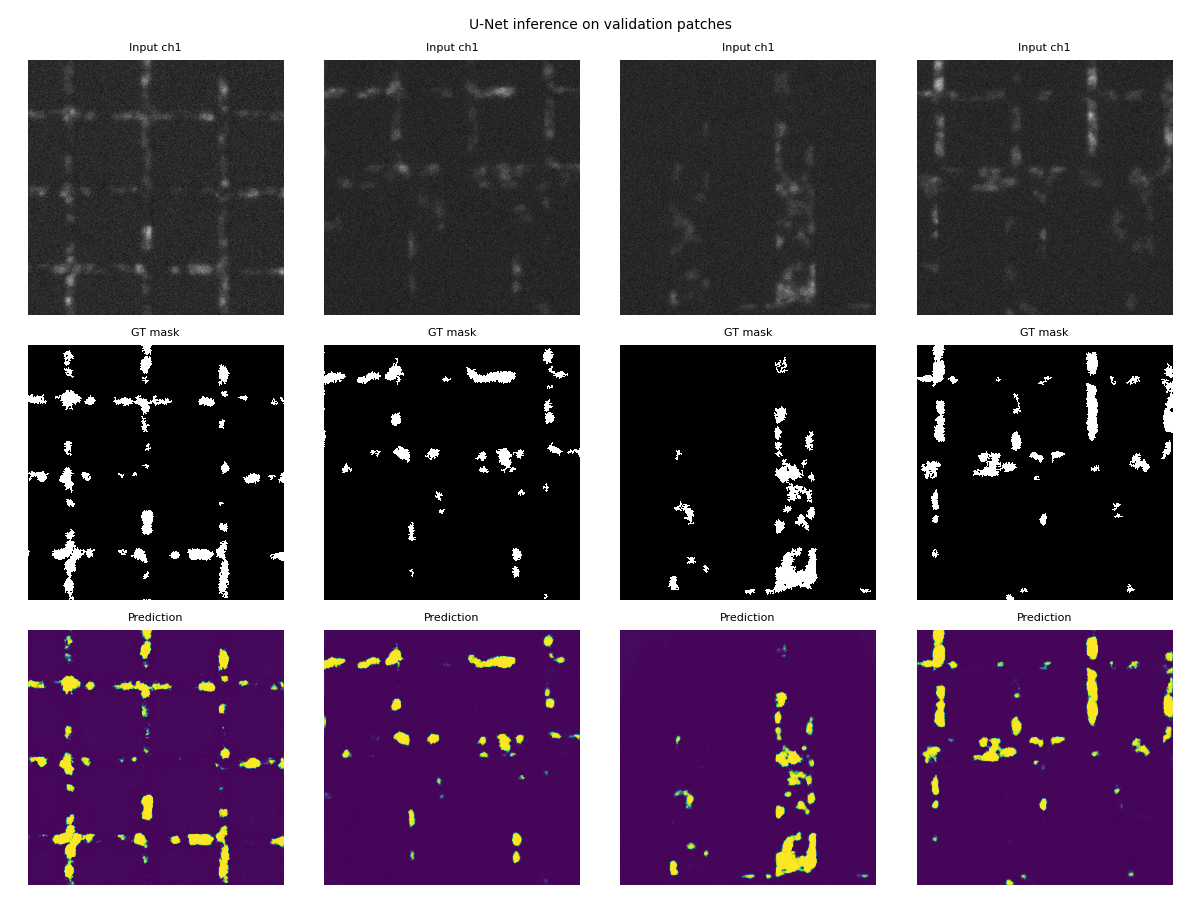

In [136]:
# ── Inference preview on validation patches ───────────────────────────────────
model.eval()

# Load the best checkpoint for clean evaluation
model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))

n_show   = min(4, n_val)
val_imgs, val_masks = [], []
for i in range(n_show):
    img_t, mask_t = val_ds[i]
    val_imgs.append(img_t)
    val_masks.append(mask_t)

imgs_batch  = torch.stack(val_imgs).to(device)
masks_batch = torch.stack(val_masks).to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(imgs_batch)).cpu().numpy()[:, 0]   # (N, H, W)

imgs_np  = imgs_batch.cpu().numpy()                                # (N, C, H, W)
masks_np = masks_batch.cpu().numpy()[:, 0]                        # (N, H, W)

fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))
for i in range(n_show):
    # Show the bacteria channel used for thresholding (channel index `channel`)
    ch_idx = min(channel, imgs_np.shape[1] - 1)
    axes[0, i].imshow(imgs_np[i, ch_idx], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Input ch{channel}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(masks_np[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("GT mask", fontsize=8)
    axes[1, i].axis("off")

    axes[2, i].imshow(preds[i], cmap="viridis", vmin=0, vmax=1)
    axes[2, i].set_title("Prediction", fontsize=8)
    axes[2, i].axis("off")

plt.suptitle("U-Net inference on validation patches", fontsize=10)
plt.tight_layout()
plt.show()

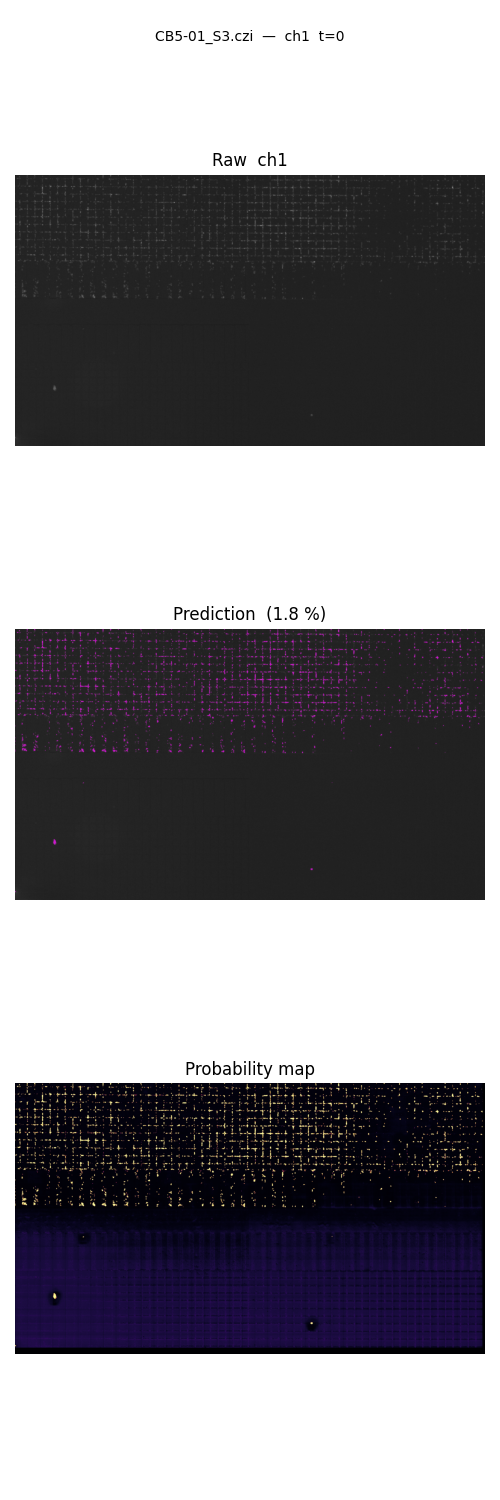


Prediction on CB5-01_S3.czi
  Coverage : 1.79 %


In [138]:
# ── Function for inference on independent images ──────────────────────────────
def predict_on_image(czi_file_path, pred_channel=1, pred_time=0, 
                     model_path=None, threshold=0.9, show_plot=True):
    """
    Run U-Net inference on a single image from a CZI file.
    
    Parameters
    ----------
    czi_file_path : str or Path
        Path to the CZI file
    pred_channel : int
        Channel index to use for display
    pred_time : int
        Time point index
    model_path : str or Path, optional
        Path to saved model checkpoint. If None, uses MODEL_SAVE.
    threshold : float
        Probability threshold for binary segmentation (0–1)
    show_plot : bool
        If True, display comparison figures
        
    Returns
    -------
    dict
        Dictionary with keys:
        - 'prob_map': (H, W) probability map
        - 'pred_binary': (H, W) binary prediction
        - 'img_multichannel': (C, H, W) input image
        - 'coverage': float in [0, 1]
    """
    from pathlib import Path
    
    czi_file_path = Path(czi_file_path)
    model_path = model_path or MODEL_SAVE
    
    # Load image
    czi_pred = CziFile(czi_file_path)
    pred_dim_sizes = dict(zip(czi_pred.dims, czi_pred.size))
    img_align, _ = get_frame(czi_pred, pred_time, 2, 
                            gamma=1, stretch_min=1, stretch_max=99.5)
    result = align_chip_to_image(img_align, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

    def select_roi(img):
        roi, _ = get_roi_from_result(
        result,
        result['rotate_fn'](img) ,
        region= "full",
        pad_left_um=-500.0,   # expand chip box leftward (µm)
        pad_right_um=-1000.0,  # expand chip box rightward (µm)
        pad_top_um=1300.0,    # pad above & below main channel centre (symmetric)
        pad_bottom_um= 1300
    )
        return roi
    img_pred_raw, _ = get_frame(czi_pred, pred_time, pred_channel, 
                                gamma=1, stretch_min=1, stretch_max=99.5)
    img_pred_roi = select_roi(img_pred_raw.astype(float))
    
    # Load all channels
    n_ch = pred_dim_sizes["C"]
    ch_imgs_pred = []
    for ch in range(n_ch):
        img_ch_raw, _ = get_frame(czi_pred, pred_time, ch, 
                                  gamma=1, stretch_min=1, stretch_max=99.5)
        img_ch_roi = select_roi(img_ch_raw.astype(float))
        img_ch_norm = exposure.rescale_intensity(img_ch_roi, out_range=(0.0, 1.0)).astype(np.float32)
        ch_imgs_pred.append(img_ch_norm)
    
    img_mc_pred = np.stack(ch_imgs_pred, axis=0)   # (C, H, W)
    
    # Sliding-window inference
    C_p, H_p, W_p = img_mc_pred.shape
    prob_sum_p = np.zeros((H_p, W_p), dtype=np.float32)
    count_p    = np.zeros((H_p, W_p), dtype=np.float32)
    
    model.eval()
    with torch.no_grad():
        for r in range(0, H_p - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
            for c in range(0, W_p - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
                patch = img_mc_pred[:, r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX]
                t     = torch.from_numpy(patch).unsqueeze(0).to(device)
                prob  = torch.sigmoid(model(t)).squeeze().cpu().numpy()
                prob_sum_p[r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX] += prob
                count_p   [r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX] += 1.0
    
    count_p = np.where(count_p == 0, 1, count_p)
    prob_map_p    = prob_sum_p / count_p
    pred_binary_p = prob_map_p >= threshold
    coverage_p    = pred_binary_p.mean()
    
    if show_plot:
        # Normalise display channel
        img_disp_pred = exposure.rescale_intensity(img_pred_roi, out_range=(0.0, 1.0))
        display_ch_p = min(pred_channel, C_p - 1)
        img_show_p = img_mc_pred[display_ch_p]
        
        fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharex=True, sharey=True)
        
        axes[0].imshow(img_disp_pred, cmap="gray")
        axes[0].set_title(f"Raw  ch{pred_channel}")
        
        ov = np.stack([img_show_p]*3, axis=-1)
        ov[pred_binary_p, 0] = ov[pred_binary_p, 0] * 0.3 + 0.7
        ov[pred_binary_p, 1] = ov[pred_binary_p, 1] * 0.3
        ov[pred_binary_p, 2] = ov[pred_binary_p, 2] * 0.3 + 0.7
        axes[1].imshow(np.clip(ov, 0, 1))
        axes[1].set_title(f"Prediction  ({coverage_p*100:.1f} %)")
        
        axes[2].imshow(prob_map_p, cmap="inferno", vmin=0, vmax=1)
        axes[2].set_title("Probability map")
        
        for ax in axes:
            ax.axis("off")
        plt.suptitle(f"{czi_file_path.name}  —  ch{pred_channel}  t={pred_time}", fontsize=10)
        plt.tight_layout()
        plt.show()
    
    return {
        "prob_map": prob_map_p,
        "pred_binary": pred_binary_p,
        "img_multichannel": img_mc_pred,
        "coverage": coverage_p,
    }


# ── Example: inference on a different sample ──────────────────────────────────
# Change these to point to a different CZI file or time point
PRED_CZI = Path(root_path, "CB5-01_S3.czi")  # or any other CZI path
PRED_CH  = 1
PRED_T   = 0

result_image = predict_on_image(PRED_CZI, pred_channel=PRED_CH, pred_time=PRED_T, threshold=0.9)
print(f"\nPrediction on {PRED_CZI.name}")
print(f"  Coverage : {result_image['coverage']*100:.2f} %")